# Intro to Python for Data Miners and Alike (part II)
@ Yuzhen Ye, yye@iu.edu

* This notebook is prepared for students who need to learn python or to refresh their python programming skill.
* See part I (python-part1-basics.ipynb) for basics about Python programming (how to write a loop etc).
* Part II (this notebook) is more about using modules important for DM and ML/AI

# Using Pandas, Numpy and matplotlib

Pandas provides a lot of tools for data analysis and manipulation.

To use Pandas, it is important to understand how data is stored and the basic data structures, and how to access the data by indexing and selecting.
* Series -- a one-dimensional labeled array holding data of any type
* Dataframe -- a two-dimensional data structure that holds data like a two-dimension array or a table with rows and columns.

The dataframe is most used, and it can be created using different ways. Examples include,
* Using Pandas.DataFrame to create by passing a Numpy array, dictionary of objects  
* Reading from a file (local or remote)
* Loading from a module, e.g., yfinance

Numpy is very useful when working with arrays. Different from dataframe, the arrays (one-dimensional, or two-dimensional tables, or higher dimensional) have no labels (rows & columns).

Series:
Jan      30
Feb      40
Mar      50
April    60
dtype: int64
Dict:
{'Temp': [30, 40, 50, 60], 'Sales': [100, 30, 40, 50]}
DataFrame:
       Temp  Sales
Jan      30    100
Feb      40     30
Mar      50     40
April    60     50


Text(0, 0.5, 'Sales')

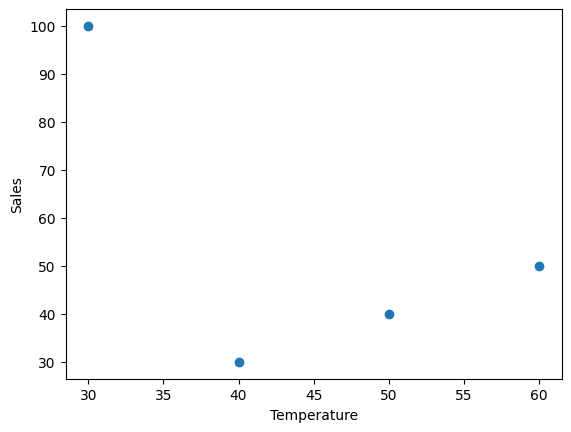

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

month = ["Jan", "Feb", "Mar", "April"]
temp = [30, 40, 50, 60]
sales = [100, 30, 40, 50]
temp_sales = [[x, y] for (x, y) in zip(temp, sales)]

s1 = pd.Series(temp, index=month)
print(f"Series:\n{s1}")

#create DataFrame from a dict
dt = {"Temp":temp, "Sales":sales}
print(f"Dict:\n{dt}")

#create a dataframe called df by passing the data (dt, a dictionary) and index (month, a series)
df1 = pd.DataFrame(dt, index=month) #same as
df1 = pd.DataFrame(dt, index=month, columns=dt.keys()) #same as
df1 = pd.DataFrame(temp_sales, index=month, columns=dt.keys())

print(f"DataFrame:\n{df1}")

#dataframe accessing
plt.plot(df1['Temp'], df1['Sales'], 'o')
plt.xlabel("Temperature")
plt.ylabel("Sales")

In [2]:
#selection by using conditions
df2 = df1[df1['Sales'] > 40]
print(df2)

       Temp  Sales
Jan      30    100
April    60     50


In [3]:
#select a column or multiple columns
df2 = df1['Temp']
print(df2)

df3 = df1[['Temp', 'Sales']]
print(df3)

Jan      30
Feb      40
Mar      50
April    60
Name: Temp, dtype: int64
       Temp  Sales
Jan      30    100
Feb      40     30
Mar      50     40
April    60     50


In [4]:
#select a row or multile rows
#using .loc with names (strings) or .iloc with indices (integers)
df2 = df1.loc['Jan'] #or
df2 = df1.iloc[0]
print(df2)

df3 = df1.loc[['Jan', 'Feb']] #or
df3 = df1.iloc[[0, 1]]
print(df3)

Temp      30
Sales    100
Name: Jan, dtype: int64
     Temp  Sales
Jan    30    100
Feb    40     30


### Create a dataframe by loading data from a remote location

In [5]:
#read from a remote file as if it were local -- so you don't need to worry about where is the data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
names = ["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm","Species"]
#iris.data has no header
iris = pd.read_csv(url, header=None, names=names)

#if you have iris.data on your computer, you can use
#df = pd.read_csv("iris.data", header=None, names=names))

print(iris)
print(f"head:\n{iris.head()}")
print(f"tail:\n{iris.tail()}")
iris.to_csv("iris.csv")

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm         Species
0              5.1           3.5            1.4           0.2     Iris-setosa
1              4.9           3.0            1.4           0.2     Iris-setosa
2              4.7           3.2            1.3           0.2     Iris-setosa
3              4.6           3.1            1.5           0.2     Iris-setosa
4              5.0           3.6            1.4           0.2     Iris-setosa
..             ...           ...            ...           ...             ...
145            6.7           3.0            5.2           2.3  Iris-virginica
146            6.3           2.5            5.0           1.9  Iris-virginica
147            6.5           3.0            5.2           2.0  Iris-virginica
148            6.2           3.4            5.4           2.3  Iris-virginica
149            5.9           3.0            5.1           1.8  Iris-virginica

[150 rows x 5 columns]
head:
   SepalLengthCm  SepalWidthCm  Pe

Often times we need to convert data between different formats, dataframe to numpy array, or create dataframe from numpy array.

In [6]:
df = pd.DataFrame(np.random.randn(6, 4), index=list(range(6)), columns=list("ABCD"))
print(df)

ar = df.to_numpy()
print(ar)

          A         B         C         D
0  0.176495  0.459186  0.071139 -0.838587
1  1.613594  0.855700  1.321952 -0.329463
2 -1.128674  0.021112  0.167970 -0.476517
3 -0.353444  1.677215 -1.170990 -0.680238
4 -1.915294  0.813728 -0.131750 -0.669891
5  2.125692 -0.988283  1.282675  1.342946
[[ 0.17649523  0.4591861   0.07113875 -0.83858698]
 [ 1.61359376  0.85570001  1.32195154 -0.32946331]
 [-1.12867407  0.02111188  0.16797044 -0.47651669]
 [-0.35344402  1.67721546 -1.17099005 -0.68023848]
 [-1.91529365  0.81372816 -0.13175032 -0.66989062]
 [ 2.12569201 -0.98828255  1.28267495  1.34294611]]


## Using a toy example to demonstrate prediction problem

The credit goes to Prof. Memo Dalklic for this problem. 

The space Challenge exploded in a min after the launch. The cause was found to be the failing of the O-rings (a type of seal). It seems that in cold weather, the rings fail more easily. Here are some data to support the hypothesis,

```
--------------------
Temp.  O-ring fails.
--------------------
0      12
10     9
25     3
35     2
--------------------
```

A brilliant scientist even came up with a formula to model the temperature-fail relationship $f(x) = 13.49(0.967)^x - 1$. So we have a model here.

A model is simply a characterization or function that relates inputs to outputs. In this case, the input is temperature, and the output is the number of O-ring fails. Models vary in terms of complexity -- they can be as simple as a straight line, or much more complex that it might be hard to understand (like the deep neural networks).

If the model is given, like the formula, it is relatively easy to predict. For example, to predict the number of O-ring fails at temperate 30 (something that we don't know yet).

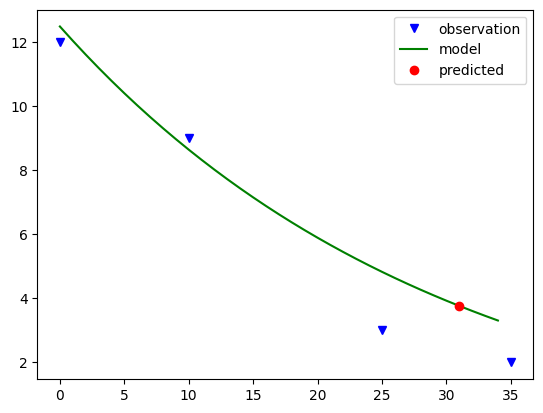

temperature = 31 predicted O-ring fails = 4


In [7]:
import math

#data
temp = [0, 10, 25, 35]
fail = [12, 9, 3, 2]

#visualze the data
plt.plot(temp, fail, "bv", label="observation")

#visualize the model
#we use so many data points (35 of them) so that the model actually shows as a smoothh line
x = list(range(0, 35))
f = [(13.49 * (0.967 ** x0) - 1) for x0 in x]
plt.plot(x, f, color="green", label="model")

#given model, it is easy to predict
t = 31
p = 13.49 * (0.967 ** t) - 1

plt.plot(t, p, 'ro', label="predicted")
plt.legend()

plt.show()
print(f"temperature = {t} predicted O-ring fails = {math.ceil(p)}")

How the model was derived? Is it the "best" model? How to define "best"?

For sure, a lot of things need to be done to create/build/train the model and to propertly evalate it so that such a model for O-ring fail predictiion can be actually useful.

# Simulation and Approximation

## Square root
Given $S$, compute its square root $x$ (i.e., $\sqrt{S}$, or $x^2 = S$).
### Heron's algorithm for approximating square root
Heron's approach (or Newton's method to solve $x^2 - S = 0$) starts with an initial guess, and iteratively revises the guess.

More precisely, if $x$ is our initial guess of $\sqrt{S}$ and $\epsilon$ is the error in our estimate such that $S=(x + \epsilon)^2$, then we have,

$(x + \epsilon)^2=x^2 + 2x\epsilon + \epsilon^2$

Solve for the error term $\epsilon$,

$\epsilon=\frac{S-x^2}{2x+\epsilon} \approx \frac{S-x^2}{2x}$ (since $\epsilon$ is much less than $x$)

So we can update the estimate as,

$x + \epsilon \approx x + \frac{S-x^2}{2x} = \frac{S+x^2}{2x} = \frac{\frac{S}{x} + x}{2}\equiv x_{revised}$.

So given $S$, we can iteratively refine its square root $x$, as follows,

$x = \frac{\frac{S}{x} + x}{2}$

When to stop? Until $\epsilon$ is very small (or $x$ doesn't change or change very little).

In [8]:
def error(S, x):
  return abs(S - x ** 2) / (2 * x)

def square_root(S, x, tao):
  while(error(S, x) > tao):
    x = (S / x + x) / 2
  return x

data = [2, 4, 9, 10]
tao = 0.00005
for S in data:
  #try different initial guesses
  x1 = square_root(S, S/2, tao)
  x2 = square_root(S, S - 1, tao)
  print(f"S={S} square root={x1} {x2}")

S=2 square root=1.4142156862745097 1.4142156862745097
S=4 square root=2.0 2.0000102400262145
S=9 square root=3.000015360039322 3.000019924608626
S=10 square root=3.162319422150883 3.162277660566801


## Approximating pi using Monte Carlo approach

The area of the blue portion is $\frac{\pi r^2}{4} = \frac{\pi}{4}$ (since $r=1$)

The area of the square is 1

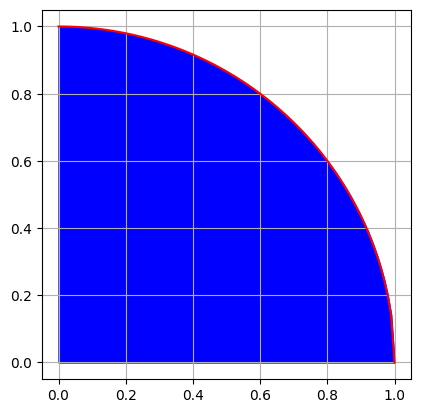

In [9]:
import matplotlib.pyplot as plt
import numpy as np
X = np.linspace(0, 1, 100)
Y = np.sqrt(1 - X ** 2)
fig = plt.figure()
ax = fig.add_subplot(111)
ax.set_aspect('equal')
plt.plot(X, Y, 'r')
plt.fill_between(X, Y, color="blue")
plt.grid()

### If we randomly sample points (x and y) in the range of [0, 1], the probability of these points found in the blue portion is the same as the area of the blue portion.

Estimation of pi = 3.11


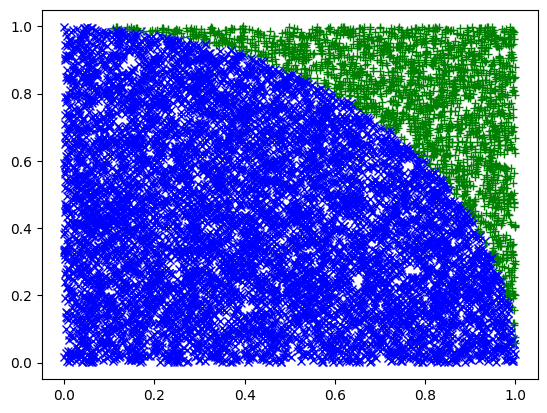

In [10]:
import math
import random as rd
#X(p): check if p is in circle or not
def X(p):
  x, y = p
  #return math.sqrt(x**2 + y**2) < 1
  return y < math.sqrt(1 - x**2)

Xdis = {True:0, False:0}
color_shape = ['g+', 'bx']
for i in range(10000):
  x, y = rd.uniform(0, 1), rd.uniform(0, 1)
  in_circle = X([x, y])
  Xdis[in_circle] += 1
  plt.plot(x, y, color_shape[int(in_circle)])
circle_area = Xdis[True] / (Xdis[True] + Xdis[False])
pi = 4 * circle_area
print(f"Estimation of pi = {pi:.2f}")